In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ISLP import load_data

Auto = load_data("Auto")
Auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1


In [41]:
median_mpg = Auto['mpg'].median()

Auto['mpg01'] = (Auto['mpg'] > median_mpg).astype(int)

Auto[['mpg', 'mpg01']].head()

,mpg,mpg01
name,,
chevrolet chevelle malibu,18.0,0
buick skylark 320,15.0,0
plymouth satellite,18.0,0
amc rebel sst,16.0,0
ford torino,17.0,0


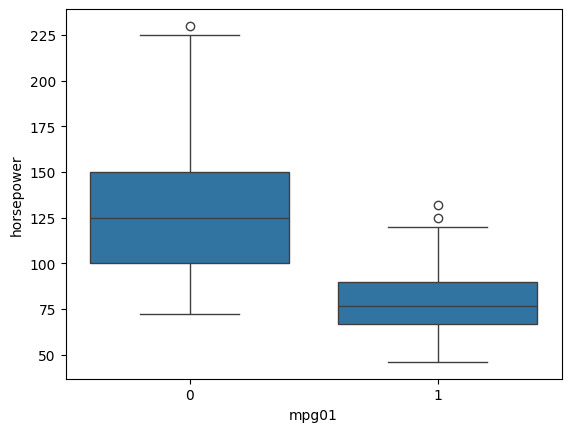

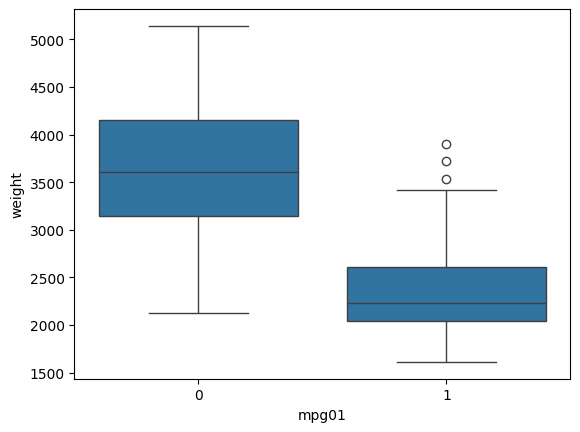

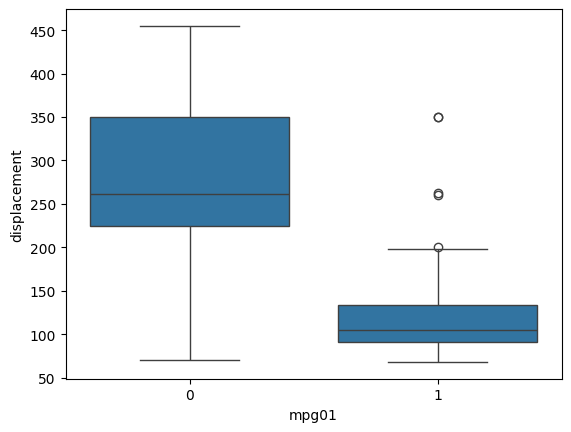

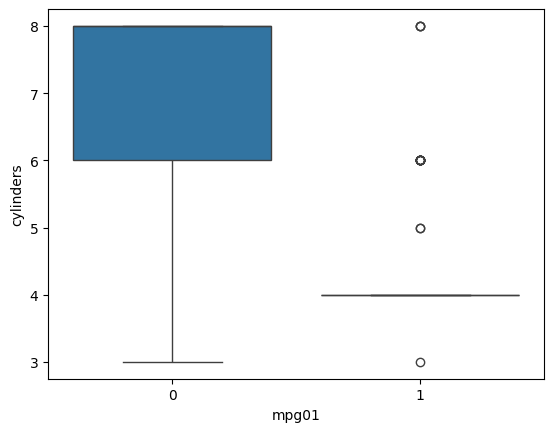

In [42]:
import seaborn as sns

sns.boxplot(x='mpg01', y='horsepower', data=Auto)
plt.show()

sns.boxplot(x='mpg01', y='weight', data=Auto)
plt.show()

sns.boxplot(x='mpg01', y='displacement', data=Auto)
plt.show()

sns.boxplot(x='mpg01', y='cylinders', data=Auto)
plt.show()

In [43]:
from sklearn.model_selection import train_test_split

X = Auto[['cylinders','displacement','horsepower','weight']]
y = Auto['mpg01']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

In [44]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

pred_lda = lda.predict(X_test)

1 - accuracy_score(y_test, pred_lda)

0.0847457627118644

In [45]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

pred_lda = lda.predict(X_test)

1 - accuracy_score(y_test, pred_lda)

0.0847457627118644

In [46]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

pred_log = logreg.predict(X_test)

1 - accuracy_score(y_test, pred_log)


0.0847457627118644

In [47]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

pred_nb = nb.predict(X_test)

1 - accuracy_score(y_test, pred_nb)

0.0847457627118644

In [48]:
from sklearn.neighbors import KNeighborsClassifier

for k in [1,3,5,10,20]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    pred_knn = knn.predict(X_test)
    
    error = 1 - accuracy_score(y_test, pred_knn)
    print(f"K={k}, error={error}")

K=1, error=0.11864406779661019
K=3, error=0.11016949152542377
K=5, error=0.13559322033898302
K=10, error=0.09322033898305082
K=20, error=0.10169491525423724
